In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## KK1 – Analys av svensk kriminalstatistik

### Om datasetet
Datasetet kommer från Brottsförebyggande rådet (BRÅ) och innehåller 
anmälda brott per 100 000 invånare i Sverige från år 1950 till 2025.

Varje rad representerar ett år. Kolumnerna visar olika brottstyper 
som misshandel, sexualbrott, stöld, narkotikabrott och totalt antal brott.

Datan mäter anmälda brott inte faktiska brott. Det betyder att 
mörkertalet är okänt och varierar mellan brottstyper.

### Frågor jag kommer att undersöka
- Hur har den totala brottsligheten utvecklats sedan 1950?
- Vilka brottstyper ökar mest?
- Finns det samband mellan olika brottstyper?

## Inläsning och mekanisk inspektion

Här läser vi in datasetet och tittar på dess grundläggande struktur.

In [65]:
df = pd.read_excel('data/10La_anm2_fr1950.xlsx', 
                   sheet_name='Statistik',
                   header=1)

df.head()


,År,Samtliga brott,"Brott mot brottsbalken (BrB), totalt","Brott mot liv och hälsa (BrB 3 kap.), totalt","Fullbordade mord, dråp, misshandel med dödlig utgång","Misshandel, grov misshandel","Sexualbrott (BrB 6 kap.), totalt","Våldtäkt, grov våldtäkt","Tillgrepps-brott (BrB 8 kap.), totalt",Inbrottsstöld,...,Biltillgrepp,Stöld ur och från motordrivet fordon,Butiksstöld,"Rån, grovt rån","Bedrägeri (BrB 9 kap.), totalt","Skadegörelsebrott (BrB 12 kap.), totalt","Brott mot övriga författningar, totalt",Brott mot narkotikastrafflagen,"Rattfylleri, grovt rattfylleri",År
0,1950,2784.0,2306.0,120.0,1.0,105.0,40.0,5.0,1578.0,295.0,...,..,..,..,3.0,209.0,72.0,477.0,0.0,49.0,1950
1,1955,3357.0,3101.0,135.0,1.0,118.0,44.0,5.0,2254.0,459.0,...,..,..,..,4.0,236.0,111.0,255.0,0.0,125.0,1955
2,1960,3982.0,3694.0,131.0,1.0,116.0,54.0,7.0,2729.0,753.0,...,244,..,..,6.0,269.0,176.0,288.0,2.0,170.0,1960
3,1965,5801.0,5090.0,167.0,3.0,151.0,51.0,8.0,3694.0,1042.0,...,397,717,123,12.0,431.0,297.0,711.0,10.0,213.0,1965
4,1970,8157.0,7002.0,247.0,1.0,228.0,41.0,9.0,4874.0,1338.0,...,402,694,288,19.0,890.0,421.0,1155.0,196.0,212.0,1970


In [66]:
# Numpy-beräkningar på brottsdata
print("Medelvärde totala brott:", np.mean(df['Samtliga brott']))
print("Standardavvikelse:", np.std(df['Samtliga brott']))
print("Max:", np.max(df['Samtliga brott']))
print("Min:", np.min(df['Samtliga brott']))

Medelvärde totala brott: 12591.588424788855
Standardavvikelse: 2921.9071612110256
Max: 15342.0726261994
Min: 2784.0


Numpy använder vi för att beräkna grundläggande statistik om brottsligheten. 
Medelvärdet ligger på cirka 12 600 brott per 100 000 invånare. 
Standardavvikelsen på nästan 3 000 visar att det varierar mycket mellan åren. 
Minimumet på 2 784 är från 1950 och maximumet på 15 342 är från 2015.

In [67]:
print(df.shape)

(56, 21)


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 21 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0    År                                                   56 non-null     int64  
 1   Samtliga brott                                        56 non-null     float64
 2   Brott mot brottsbalken (BrB), totalt                  56 non-null     float64
 3   Brott mot liv och hälsa (BrB 3 kap.), totalt          56 non-null     float64
 4   Fullbordade mord, dråp, misshandel med dödlig utgång  56 non-null     float64
 5   Misshandel, grov misshandel                           56 non-null     float64
 6   Sexualbrott (BrB 6 kap.), totalt                      56 non-null     float64
 7   Våldtäkt, grov våldtäkt                               56 non-null     float64
 8   Tillgrepps-brott (BrB 8 kap.), totalt                 56 non-null     flo

### Statistisk sammanfattning

`describe()` visar min, max, medelvärde och standardavvikelse för varje kolumn.
Vi kan redan se att totala antalet brott varierar kraftigt mellan åren.

In [69]:
df.describe()

,År,Samtliga brott,"Brott mot brottsbalken (BrB), totalt","Brott mot liv och hälsa (BrB 3 kap.), totalt","Fullbordade mord, dråp, misshandel med dödlig utgång","Misshandel, grov misshandel","Sexualbrott (BrB 6 kap.), totalt","Våldtäkt, grov våldtäkt","Tillgrepps-brott (BrB 8 kap.), totalt",Inbrottsstöld,"Rån, grovt rån","Bedrägeri (BrB 9 kap.), totalt","Skadegörelsebrott (BrB 12 kap.), totalt","Brott mot övriga författningar, totalt",Brott mot narkotikastrafflagen,"Rattfylleri, grovt rattfylleri",År
count,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,1996.428571,12591.588425,10704.403245,632.490775,2.423754,593.148255,115.244845,36.498503,6085.579923,1271.636629,65.195160,1104.094146,1295.354300,1880.382337,594.002415,244.896972,1996.428571
std,18.382657,2948.350299,2452.810522,275.169116,1.046269,259.126895,73.327892,29.708703,1780.742828,441.124813,28.707697,607.485462,570.578766,663.280592,351.743689,54.443986,18.382657
min,1950.000000,2784.000000,2306.000000,120.000000,1.000000,105.000000,29.000000,5.000000,1578.000000,295.000000,3.000000,209.000000,72.000000,255.000000,0.000000,49.000000,1950.000000
25%,1983.750000,11811.000000,10027.000000,391.500000,2.000000,364.500000,49.000000,11.750000,5024.337600,908.719210,42.000000,631.000000,853.000000,1474.500000,344.000000,218.250000,1983.750000
50%,1997.500000,13567.673248,11789.011371,664.500000,2.000000,633.500000,94.000000,22.406533,6209.500000,1345.389889,70.000000,1062.904949,1293.108883,1727.145575,463.000000,255.000000,1997.500000
75%,2011.250000,14296.975048,12136.586040,889.142755,3.000000,826.401260,181.487988,63.583181,7663.216065,1668.250000,89.625612,1274.198055,1764.083665,2533.421637,939.385630,277.500000,2011.250000
max,2025.000000,15342.072626,12803.301824,1005.000000,5.000000,947.000000,265.366554,94.203166,8650.000000,1878.000000,104.000000,2557.784168,2250.818946,2952.377658,1232.739768,337.000000,2025.000000


### Datatvätt

BRÅ använder ".." för att markera att data saknas för vissa år och brottstyper. 
Python förstår inte ".." som ett tomt värde, så vi ersätter dem med NaN 
(Not a Number) som är pandas sätt att hantera saknad data.

In [70]:
df.isnull().sum()

 År                                                     0
Samtliga brott                                          0
Brott mot brottsbalken (BrB), totalt                    0
Brott mot liv och hälsa (BrB 3 kap.), totalt            0
Fullbordade mord, dråp, misshandel med dödlig utgång    0
Misshandel, grov misshandel                             0
Sexualbrott (BrB 6 kap.), totalt                        0
Våldtäkt, grov våldtäkt                                 0
Tillgrepps-brott (BrB 8 kap.), totalt                   0
Inbrottsstöld                                           0
Bostads-inbrott                                         0
Biltillgrepp                                            0
Stöld ur och från motordrivet fordon                    0
Butiksstöld                                             0
Rån, grovt rån                                          0
Bedrägeri (BrB 9 kap.), totalt                          0
Skadegörelsebrott (BrB 12 kap.), totalt                 0
Brott mot övri

In [71]:
df[df == '..'].count()

 År                                                     0
Samtliga brott                                          0
Brott mot brottsbalken (BrB), totalt                    0
Brott mot liv och hälsa (BrB 3 kap.), totalt            0
Fullbordade mord, dråp, misshandel med dödlig utgång    0
Misshandel, grov misshandel                             0
Sexualbrott (BrB 6 kap.), totalt                        0
Våldtäkt, grov våldtäkt                                 0
Tillgrepps-brott (BrB 8 kap.), totalt                   0
Inbrottsstöld                                           0
Bostads-inbrott                                         3
Biltillgrepp                                            2
Stöld ur och från motordrivet fordon                    3
Butiksstöld                                             3
Rån, grovt rån                                          0
Bedrägeri (BrB 9 kap.), totalt                          0
Skadegörelsebrott (BrB 12 kap.), totalt                 0
Brott mot övri

In [72]:
df = df.replace('..', np.nan)
df = df.replace('.', np.nan)

df.isnull().sum()

 År                                                     0
Samtliga brott                                          0
Brott mot brottsbalken (BrB), totalt                    0
Brott mot liv och hälsa (BrB 3 kap.), totalt            0
Fullbordade mord, dråp, misshandel med dödlig utgång    0
Misshandel, grov misshandel                             0
Sexualbrott (BrB 6 kap.), totalt                        0
Våldtäkt, grov våldtäkt                                 0
Tillgrepps-brott (BrB 8 kap.), totalt                   0
Inbrottsstöld                                           0
Bostads-inbrott                                         3
Biltillgrepp                                            2
Stöld ur och från motordrivet fordon                    3
Butiksstöld                                             3
Rån, grovt rån                                          0
Bedrägeri (BrB 9 kap.), totalt                          0
Skadegörelsebrott (BrB 12 kap.), totalt                 0
Brott mot övri

### Utforskning genom visualisering

**Fråga: Hur har den totala brottsligheten i Sverige utvecklats sedan 1950?**

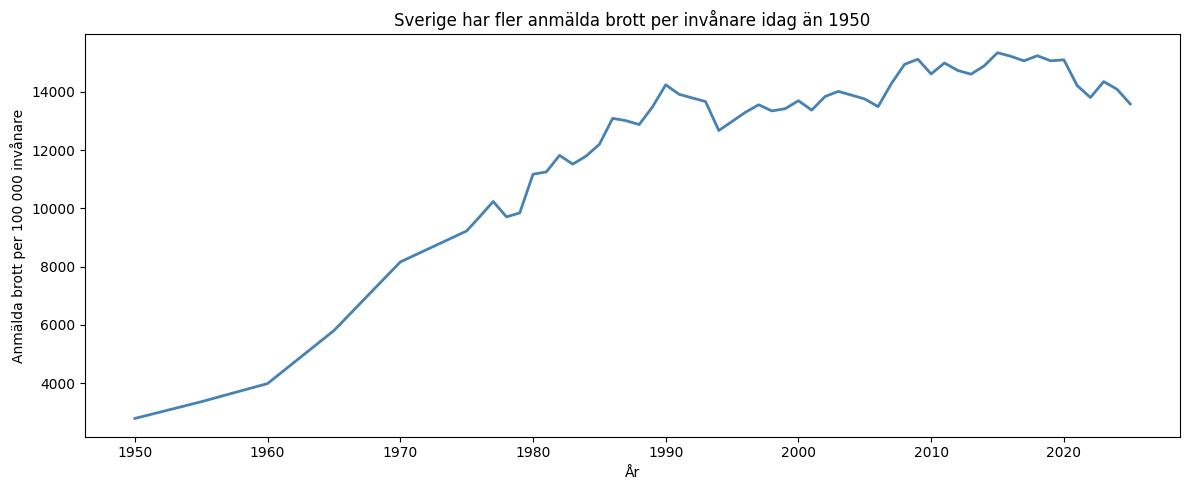

In [73]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['År'], df['Samtliga brott'], color='steelblue', linewidth=2)

ax.set_title('Sverige har fler anmälda brott per invånare idag än 1950')
ax.set_xlabel('År')
ax.set_ylabel('Anmälda brott per 100 000 invånare')

plt.tight_layout()
plt.show()

### Grafen visar en tydlig ökning från 1960 fram till runt 2020. Det är intressant eftersom media ofta rapporterar om ökande brottslighet, men kurvan pekar faktiskt nedåt de senaste åren. En viktig sak att tänka på är att statistiken bara visar anmälda brott — inte faktiska brott. Det betyder att mörkertalet kan påverka bilden.

### Visualisering 2 - Utveckling av våldsbrott över tid

**Fråga: Vilka våldsbrott ökar mest och hur har de utvecklats över tid?**

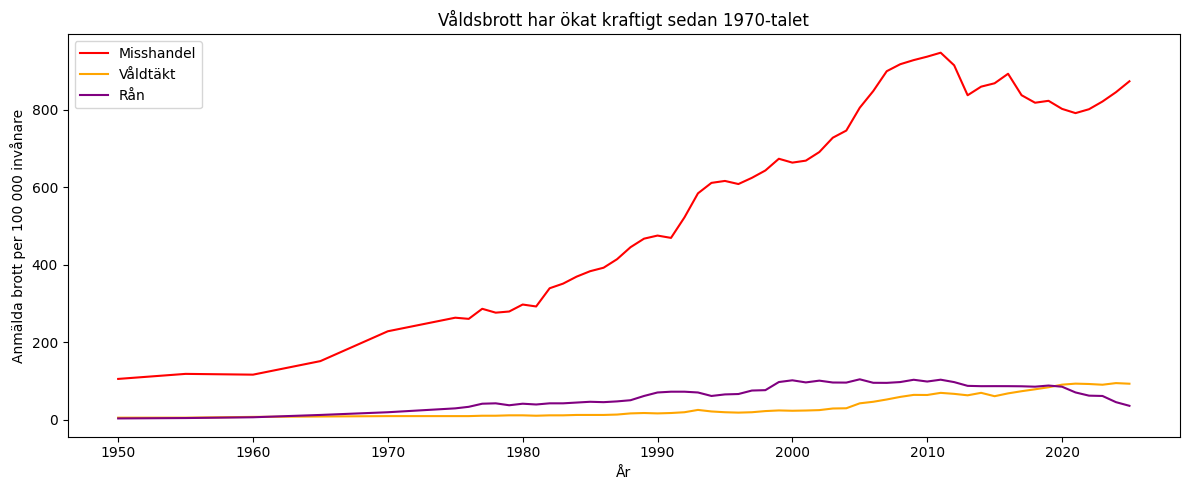

In [74]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['År'], df['Misshandel, grov misshandel'], label='Misshandel', color='red')
ax.plot(df['År'], df['Våldtäkt, grov våldtäkt'], label='Våldtäkt', color='orange')
ax.plot(df['År'], df['Rån, grovt rån'], label='Rån', color='purple')

ax.set_title('Våldsbrott har ökat kraftigt sedan 1970-talet')
ax.set_xlabel('År')
ax.set_ylabel('Anmälda brott per 100 000 invånare')
ax.legend()

plt.tight_layout()
plt.show()

### Misshandel ökar kraftigt från 1970-talet. Det är frestande att koppla detta till politiska eller samhälleliga förändringar, men statistiken visar bara ett mönster inte orsaken bakom det.

### Visualisering 3 - Fördelning av total brottslighet

**Fråga: Hur är den totala brottsligheten fördelad över åren?**

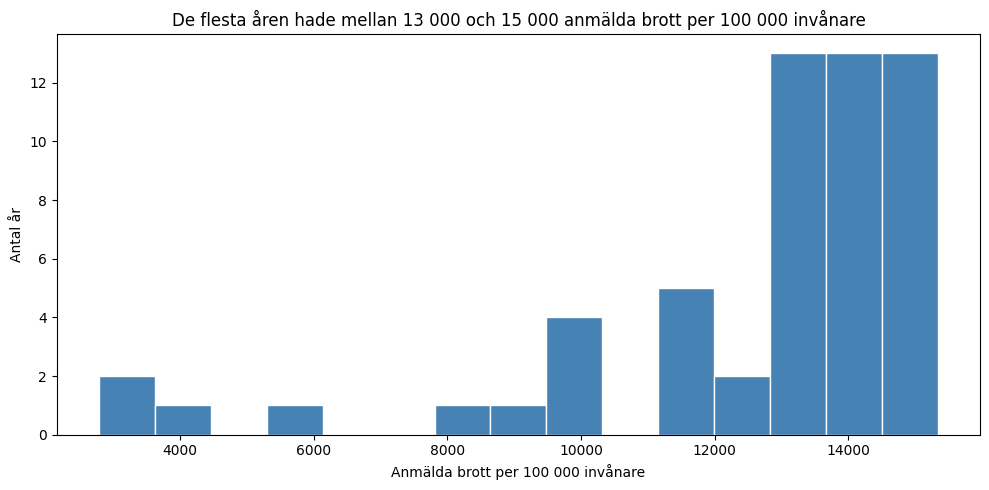

In [75]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['Samtliga brott'], bins=15, color='steelblue', edgecolor='white')

ax.set_title('De flesta åren hade mellan 13 000 och 15 000 anmälda brott per 100 000 invånare')
ax.set_xlabel('Anmälda brott per 100 000 invånare')
ax.set_ylabel('Antal år')

plt.tight_layout()
plt.show()

### Reflektion histogram

Ett histogram visar hur ofta olika värden förekommer. Här ser vi att 
de flesta åren i datasetet hade mellan 13 000 och 15 000 anmälda brott 
per 100 000 invånare. Det betyder att brottsligheten varit relativt 
stabil under stora delar av perioden, men att det finns år som sticker 
ut i båda riktningarna.

### Visualisering 4 - Samband mellan misshandel och narkotikabrott

**Fråga: Finns det ett samband mellan narkotikabrott och misshandel?**

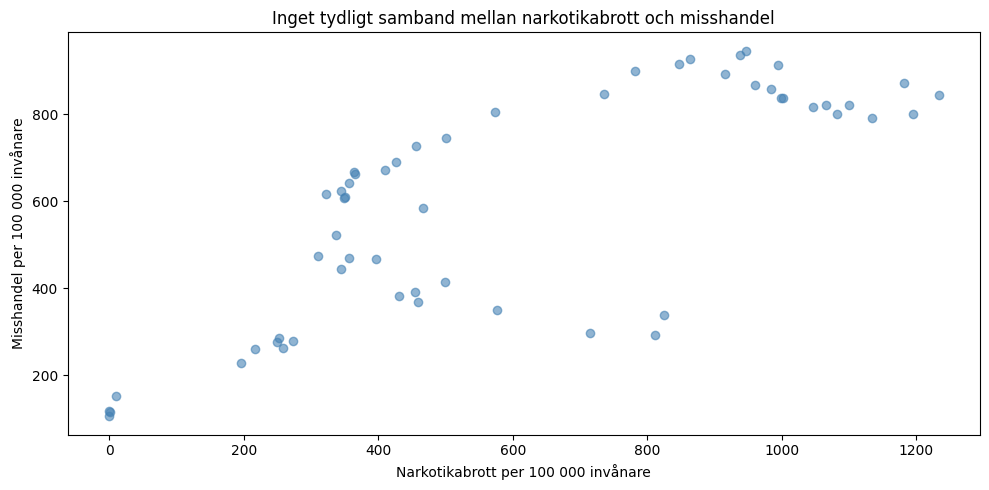

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df['Brott mot narkotikastrafflagen'], 
           df['Misshandel, grov misshandel'], 
           color='steelblue', alpha=0.6)

ax.set_title('Inget tydligt samband mellan narkotikabrott och misshandel')
ax.set_xlabel('Narkotikabrott per 100 000 invånare')
ax.set_ylabel('Misshandel per 100 000 invånare')

plt.tight_layout()
plt.show()

### Reflektion scatterplot

Ett scatterplot visar sambandet mellan två variabler. Varje punkt 
representerar ett år. Punkterna är relativt utspridda vilket tyder på 
att det inte finns ett tydligt samband mellan narkotikabrott och 
misshandel i Sverige. Även om båda ökat över tid så följer de inte 
samma mönster år för år.

### Visualisering 5 - Spridning av brottstyper över tid

**Fråga: Vilken brottstyp varierar mest över tid?**

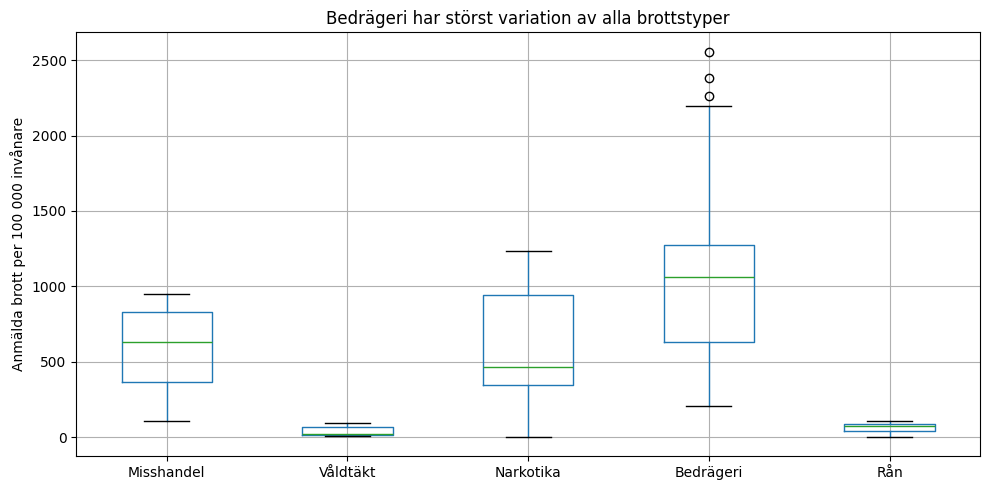

In [77]:
data = df[['Misshandel, grov misshandel', 
           'Våldtäkt, grov våldtäkt',
           'Brott mot narkotikastrafflagen',
           'Bedrägeri (BrB 9 kap.), totalt',
           'Rån, grovt rån']].copy()

data.columns = ['Misshandel', 'Våldtäkt', 'Narkotika', 'Bedrägeri', 'Rån']

fig, ax = plt.subplots(figsize=(10, 5))
data.boxplot(ax=ax)

ax.set_title('Bedrägeri har störst variation av alla brottstyper')
ax.set_ylabel('Anmälda brott per 100 000 invånare')

plt.tight_layout()
plt.show()

### Reflektion boxplot

En boxplot visar hur mycket ett värde varierar över tid. Ju större box, 
desto mer variation. Bedrägeri sticker ut tydligt med störst box vilket 
bekräftar det vi såg i linjediagrammet — det är den brottstyp som 
förändrats mest i Sverige sedan 1950.

### Avslutning - vad jag lärt mig och vad jag inte kan veta

Analysen visar att brottsligheten i Sverige ökat kraftigt sedan 1950, 
men att trenden planat ut de senaste åren. Våldsbrott och narkotikabrott 
ökade markant från 1970-talet, medan bedrägerier exploderat i takt med 
digitaliseringen.

Det finns dock mycket datan inte kan berätta. Statistiken mäter bara 
anmälda brott — inte faktiska brott. Mörkertalet varierar kraftigt mellan 
brottstyper. Sexualbrott anmäls i mycket lägre grad än stöld, vilket gör 
jämförelser svåra.

Frågor som förblev obesvarade är hur brottsligheten ser ut på regional 
nivå och om det finns skillnader mellan olika befolkningsgrupper.